In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
x = 6*np.random.rand(100,1)-3

In [4]:
y = 0.5 * x**2 + 1.5*x + 2 + np.random.randn(100,1)

Text(0, 0.5, 'y points')

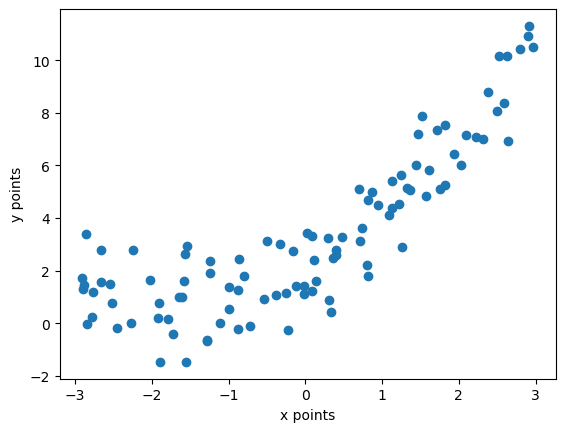

In [5]:
plt.scatter(x,y)
plt.xlabel('x points')
plt.ylabel('y points')

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [9]:
regression_1.fit(x_train,y_train)

LinearRegression()

In [10]:
from sklearn.metrics import r2_score
score = r2_score(y_test,regression_1.predict(x_test))
print(score)

0.5894241889771583


Text(0, 0.5, 'y dataset')

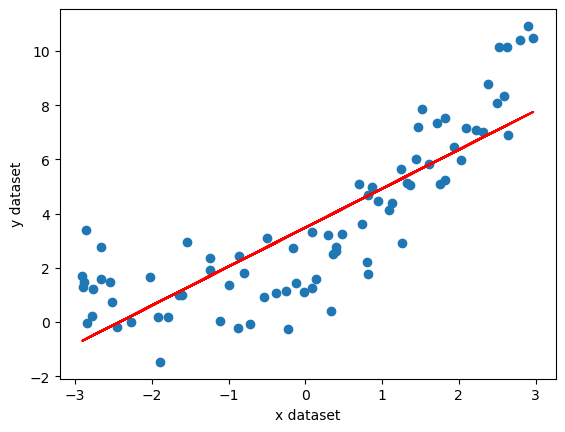

In [11]:
plt.plot(x_train,regression_1.predict(x_train),color='r')
plt.scatter(x_train,y_train)
plt.xlabel('x dataset')
plt.ylabel('y dataset')

# Applying polynomial transformation for making a best fit curved line

In [13]:
from sklearn.preprocessing import PolynomialFeatures

In [14]:
poly = PolynomialFeatures(degree=2,include_bias=True)

In [15]:
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [16]:
x_train

array([[ 0.33493537],
       [-2.27041129],
       [-1.5484334 ],
       [-2.02350842],
       [ 0.39303085],
       [-2.77561246],
       [ 0.29440971],
       [ 2.58451004],
       [-2.84375661],
       [ 1.43849125],
       [-0.54613392],
       [ 1.26350417],
       [-1.7854672 ],
       [ 1.24324591],
       [ 1.08840421],
       [ 2.38275503],
       [-1.24320425],
       [-0.01783982],
       [ 2.63471152],
       [ 1.36321667],
       [-0.16828372],
       [-2.85967434],
       [ 2.02704595],
       [ 2.22912412],
       [ 0.39818338],
       [ 0.86864191],
       [ 2.52314558],
       [-0.4982501 ],
       [-0.79826096],
       [-0.99503874],
       [ 2.31333166],
       [-2.88833158],
       [-1.92189492],
       [ 2.96864196],
       [ 2.09856541],
       [-2.76697212],
       [ 0.94447511],
       [ 2.90625897],
       [-0.38751746],
       [ 0.80084315],
       [ 1.93115032],
       [ 2.80179795],
       [-1.89595998],
       [-0.87005124],
       [ 1.61226887],
       [ 0

In [17]:
x_train_poly # first col is bias , second col is actual x_train , third col is square of the second one ----> Here we increased the degree of the equation to make it polynomial and to fit a curved line on the dataset inorder to minimize the error

array([[ 1.00000000e+00,  3.34935368e-01,  1.12181701e-01],
       [ 1.00000000e+00, -2.27041129e+00,  5.15476745e+00],
       [ 1.00000000e+00, -1.54843340e+00,  2.39764599e+00],
       [ 1.00000000e+00, -2.02350842e+00,  4.09458633e+00],
       [ 1.00000000e+00,  3.93030854e-01,  1.54473252e-01],
       [ 1.00000000e+00, -2.77561246e+00,  7.70402453e+00],
       [ 1.00000000e+00,  2.94409708e-01,  8.66770759e-02],
       [ 1.00000000e+00,  2.58451004e+00,  6.67969213e+00],
       [ 1.00000000e+00, -2.84375661e+00,  8.08695163e+00],
       [ 1.00000000e+00,  1.43849125e+00,  2.06925707e+00],
       [ 1.00000000e+00, -5.46133920e-01,  2.98262259e-01],
       [ 1.00000000e+00,  1.26350417e+00,  1.59644278e+00],
       [ 1.00000000e+00, -1.78546720e+00,  3.18789313e+00],
       [ 1.00000000e+00,  1.24324591e+00,  1.54566039e+00],
       [ 1.00000000e+00,  1.08840421e+00,  1.18462372e+00],
       [ 1.00000000e+00,  2.38275503e+00,  5.67752155e+00],
       [ 1.00000000e+00, -1.24320425e+00

In [18]:
from sklearn.linear_model import LinearRegression
regression_poly = LinearRegression()

In [19]:
regression_poly.fit(x_train_poly,y_train)

LinearRegression()

In [20]:
from sklearn.metrics import r2_score
poly_score = r2_score(y_test,regression_poly.predict(x_test_poly))
print(poly_score)

0.8159911578832039


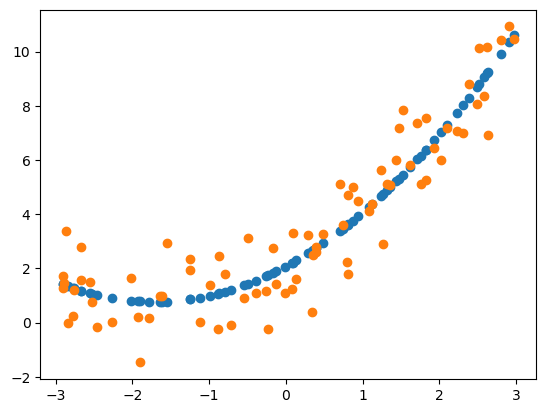

In [21]:
plt.scatter(x_train,regression_poly.predict(x_train_poly))
plt.scatter(x_train,y_train)

In [42]:
from sklearn.pipeline import Pipeline

In [74]:
def poly_regression(degree):
    x_new = np.linspace(-3,3,200).reshape(200,1)
    poly_features = PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg = LinearRegression()
    poly_reg = Pipeline([
        ('poly_features',poly_features),
        ('lin_reg',lin_reg)
    ])
    poly_reg.fit(x_train,y_train)
    y_pred_new = poly_reg.predict(x_new)
    plt.plot(x_new,y_pred_new,'r',label='Degree'+str(degree),linewidth=3)
    plt.plot(x_train,y_train,'b.',label='Training data',linewidth=3)
    plt.plot(x_test,y_test,'g.',label='Testing data',linewidth=3)
    plt.legend(loc='upper left')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis([-4,4,0,10])
    plt.show()

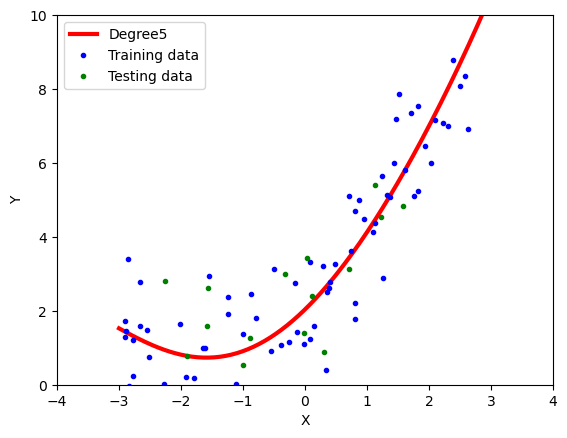

In [76]:
poly_regression(5)